In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader, Subset

# Add the directory containing utils.py to the system path
sys.path.append(r"..\..\..\Utils")
from utils import ResizedSPARKDataset

# CONFIGURATION
ROOT_DIR = r"c:\Users\Stefano\Documents\Uni\UniLu\JupyterServers\CVIA\data"
MODEL_PATH = r"..\..\..\models\segmentation\unet\best_model.pth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class_map = {
    'VenusExpress': 0, 'Cheops': 1, 'LisaPathfinder': 2, 'ObservationSat1': 3,
    'Proba2': 4, 'Proba3': 5, 'Proba3ocs': 6, 'Smart1': 7, 'Soho': 8, 'XMM Newton': 9
}

print(f"Using device: {DEVICE}")

Using device: cuda


In [5]:
# 1. Initialize the same architecture used during training
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None, # Set to None as we load our local weights
    in_channels=3,
    classes=3
).to(DEVICE)

# 2. Load the state dictionary
if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval() # Set to evaluation mode
    print(f"Model successfully loaded from: {MODEL_PATH}")
    if 'epoch' in checkpoint:
        print(f"Checkpoint reached at epoch: {checkpoint['epoch']}")
else:
    print(f"ERROR: No checkpoint found at {MODEL_PATH}")

ERROR: No checkpoint found at ..\..\models\segmentation\unet\best_model.pth


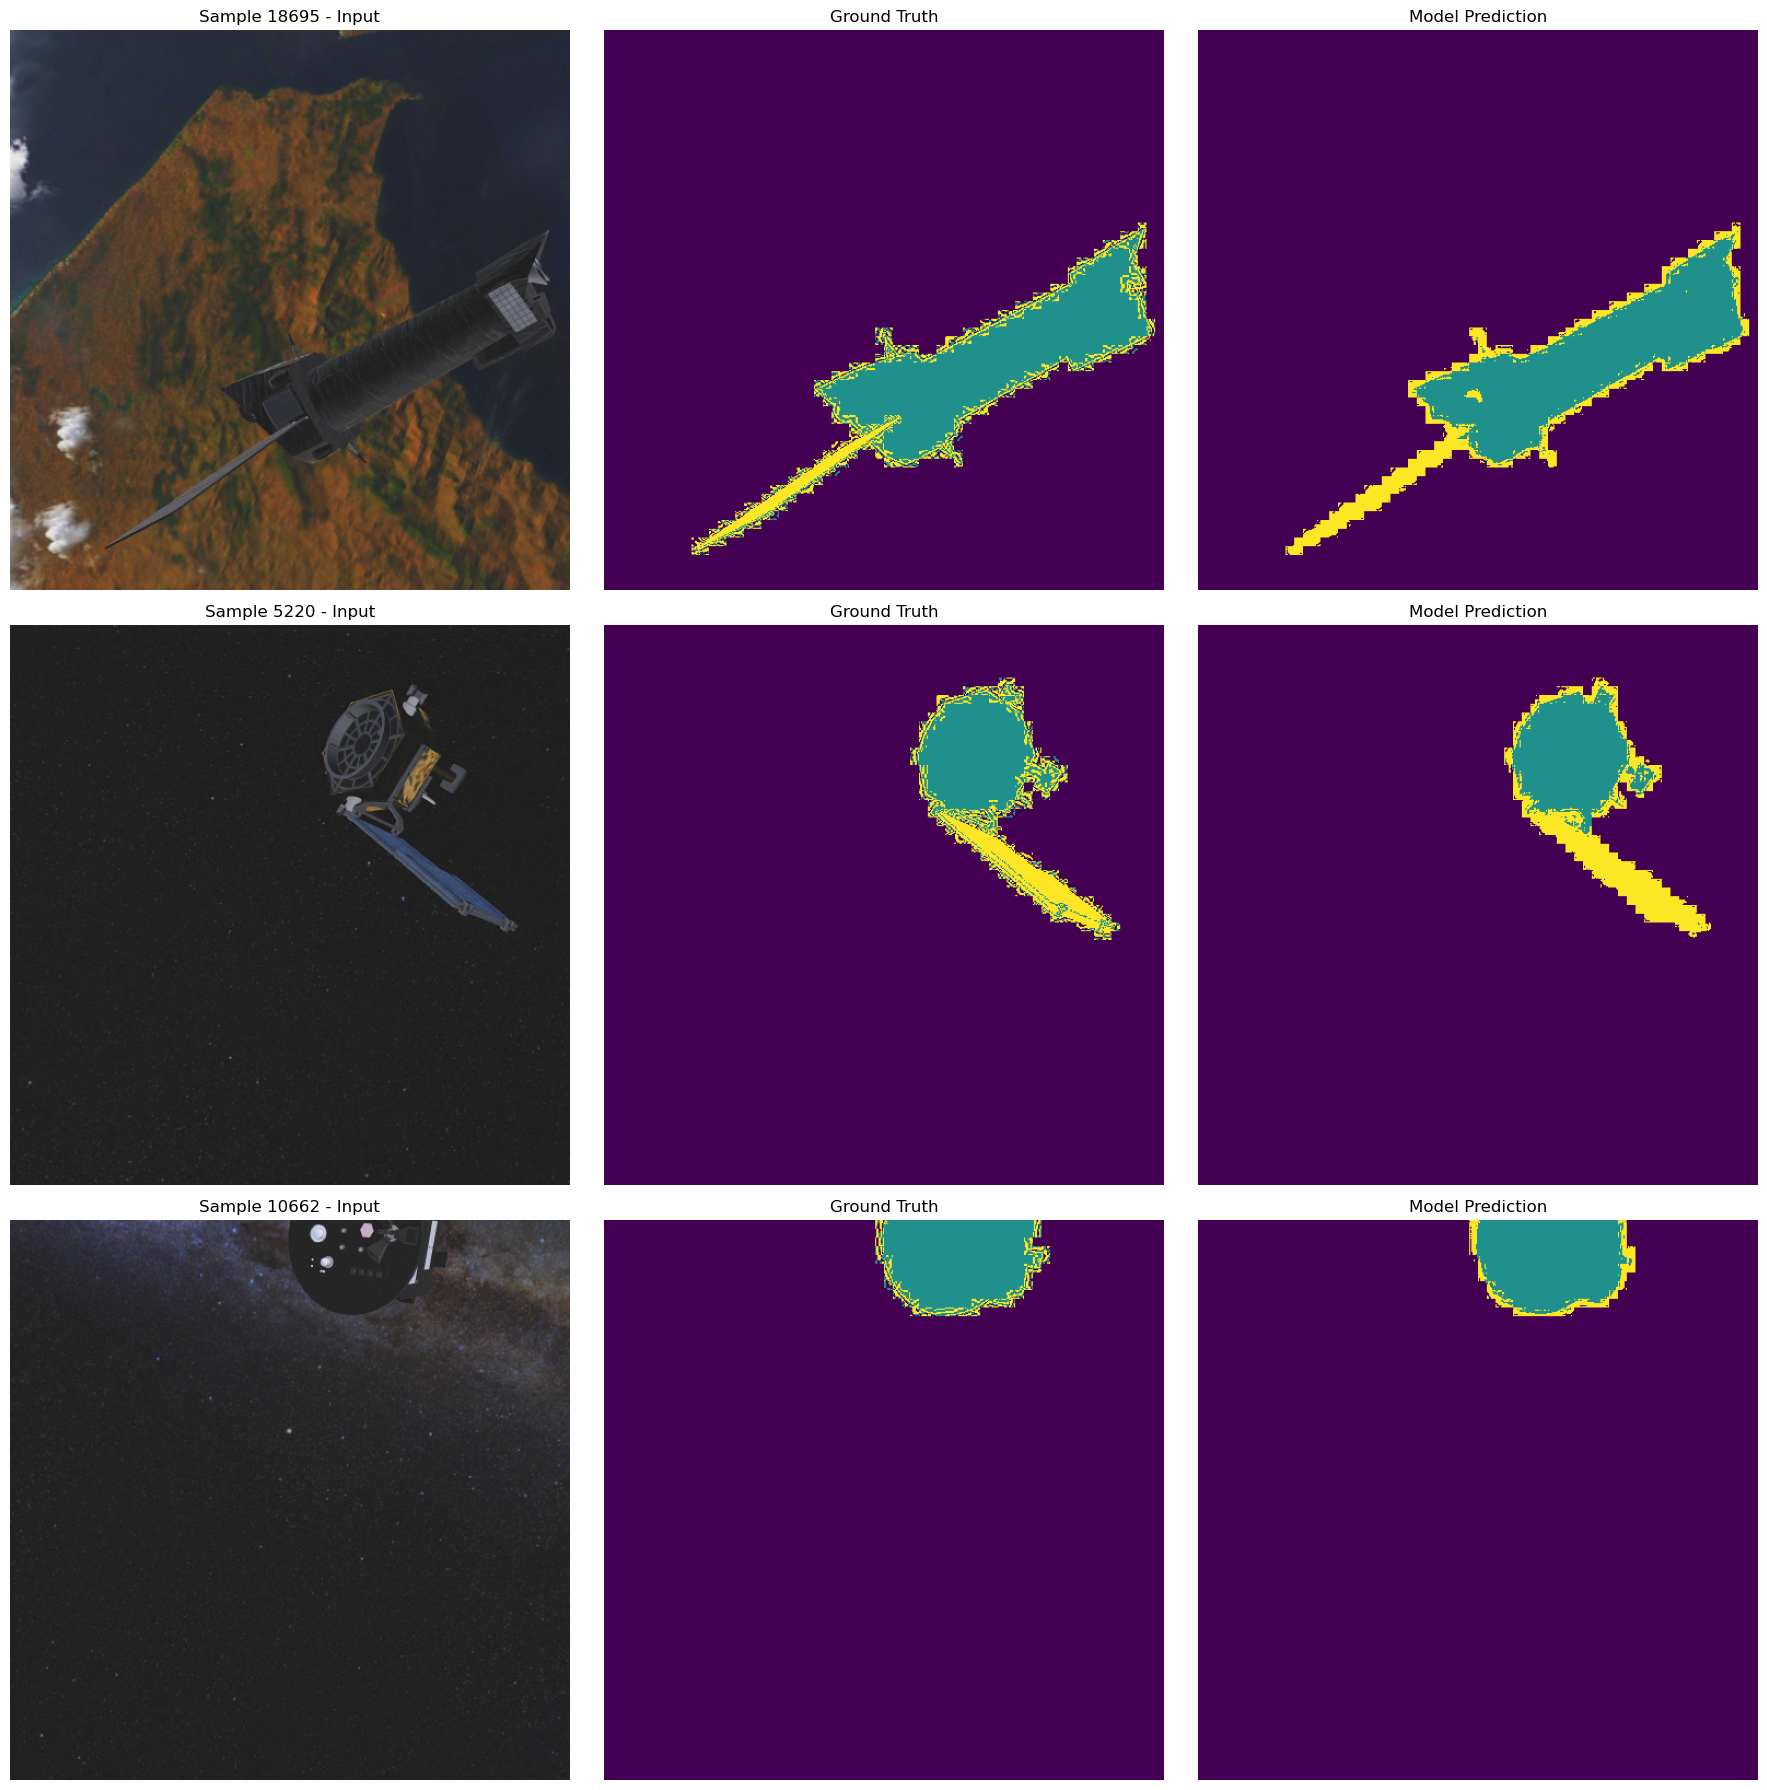

In [ ]:
def run_visual_test(num_samples=3):
    # Instantiate the validation dataset
    val_dataset = ResizedSPARKDataset(
        class_map=class_map, 
        root_dir=ROOT_DIR, 
        split='val', 
        target_size=(512, 512)
    )
    
    # Pick random indices
    indices = np.random.choice(len(val_dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(18, 6 * num_samples))

    for i, idx in enumerate(indices):
        sample = val_dataset[idx]
        img_tensor = sample['img'].to(DEVICE).unsqueeze(0) # [1, 3, 512, 512]
        
        # --- INFERENCE ---
        with torch.no_grad():
            output = model(img_tensor)
            # Convert 3-channel output to single class-index map via Argmax
            pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

        # --- DATA PREPARATION FOR VISUALIZATION ---
        # Image: Convert (C, H, W) -> (H, W, C) for Matplotlib
        input_img = sample['img'].permute(1, 2, 0).cpu().numpy()
        input_img = np.clip(input_img, 0, 1)

        # Ground Truth: Reconstruct indices from RGB channels (0:BG, 1:Red, 2:Blue) #TODO UPDATE LOGIC -> this is wrong
        gt_rgb = sample['mask']
        gt_mask = np.zeros((512, 512))
        gt_mask[gt_rgb[0] > 0] = 1 
        gt_mask[gt_rgb[2] > 0] = 2

        # --- PLOTTING ---
        # Original Image
        axes[i, 0].imshow(input_img)
        axes[i, 0].set_title(f"Sample {idx} - Input")
        
        # Ground Truth
        axes[i, 1].imshow(gt_mask, cmap='viridis', vmin=0, vmax=2)
        axes[i, 1].set_title("Ground Truth")
        
        # Prediction
        axes[i, 2].imshow(pred_mask, cmap='viridis', vmin=0, vmax=2)
        axes[i, 2].set_title("Model Prediction")

        for ax in axes[i]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Execute the test
run_visual_test(num_samples=3)

In [9]:
from tqdm import tqdm
from torch.utils.data import Subset

def evaluate_model(fraction=1.0, num_classes=3):
    """
    Evaluates the model on a fraction of the validation set.
    fraction=1.0 runs on the whole set.
    fraction=0.1 runs on 10% of the set.
    """
    # 1. Setup Dataset
    full_val_dataset = ResizedSPARKDataset(
        class_map=class_map, 
        root_dir=ROOT_DIR, 
        split='val', 
        target_size=(512, 512)
    )

    # 2. Handle Fractioning
    if fraction < 1.0:
        num_samples = int(len(full_val_dataset) * fraction)
        # Randomly select indices for the subset
        indices = np.random.choice(len(full_val_dataset), num_samples, replace=False)
        val_dataset = Subset(full_val_dataset, indices)
        print(f"Evaluating on a subset of {num_samples} images (Fraction: {fraction})...")
    else:
        val_dataset = full_val_dataset
        print(f"Evaluating on the full validation set ({len(val_dataset)} images)...")

    # 3. Setup DataLoader
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

    # Accumulators
    total_correct_pixels = 0
    total_pixels = 0
    intersections = np.zeros(num_classes)
    unions = np.zeros(num_classes)

    model.eval()

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating", unit="batch"):
            imgs = batch['img'].to(DEVICE)
            masks_rgb = batch['mask'].to(DEVICE)

            # Reconstruct Target Mask indices (0, 1, 2)
            targets = torch.zeros((imgs.shape[0], 512, 512), dtype=torch.long, device=DEVICE)
            targets[(masks_rgb[:, 0, :, :] > 0)] = 1 # Red channel
            targets[(masks_rgb[:, 2, :, :] > 0)] = 2 # Blue channel

            # Forward Pass
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1) 

            # Accuracy calculation
            total_correct_pixels += (preds == targets).sum().item()
            total_pixels += targets.numel()

            # IoU calculation per class
            for cls in range(num_classes):
                pred_inds = (preds == cls)
                target_inds = (targets == cls)
                
                intersection = (pred_inds & target_inds).sum().item()
                union = (pred_inds | target_inds).sum().item()
                
                intersections[cls] += intersection
                unions[cls] += union

    # 4. Final Calculations
    pixel_acc = total_correct_pixels / total_pixels
    iou_per_class = [intersections[i] / unions[i] if unions[i] != 0 else 0 for i in range(num_classes)]
    mean_iou = np.mean(iou_per_class)

    # 5. Report
    print("\n" + "="*40)
    print("      SEGMENTATION REPORT (FRACTION)")
    print("="*40)
    print(f"Overall Pixel Accuracy: {pixel_acc:.4%}")
    print(f"Mean IoU:               {mean_iou:.4f}")
    print("-" * 40)
    class_names = ["Background", "Satellite Body", "Solar Panels"]
    for i, iou in enumerate(iou_per_class):
        print(f"IoU {class_names[i]:<15}: {iou:.4f}")
    print("="*40)



In [10]:
evaluate_model(fraction=0.3)

Evaluating on a subset of 6000 images (Fraction: 0.3)...


Evaluating:   0%|          | 0/188 [00:00<?, ?batch/s]

Evaluating: 100%|██████████| 188/188 [01:12<00:00,  2.58batch/s]


      SEGMENTATION REPORT (FRACTION)
Overall Pixel Accuracy: 98.8857%
Mean IoU:               0.8077
----------------------------------------
IoU Background     : 0.9958
IoU Satellite Body : 0.7801
IoU Solar Panels   : 0.6470
